In [11]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm

In [12]:
original_db= sc.read_h5ad("adata_pmbc_10k_original.h5ad")
original_db

AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts'
    uns: 'cell_types'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc'

In [15]:
# Use Geneformer generated embedded data and attach true cell type labels to the embedded data
adata= sc.read_h5ad("PBMC10k_geneformer.h5ad")
adata.uns['cell_types'] = original_db.uns['cell_types']
adata

AnnData object with n_obs × n_vars = 11990 × 512
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    uns: 'cell_types'

### Direct integration UMAP without Harmony correction

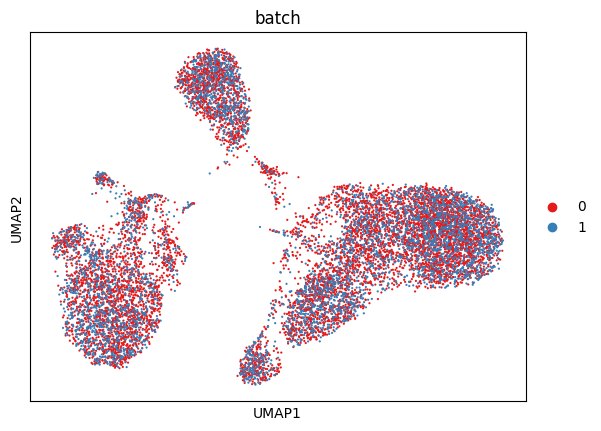

In [19]:
#Compute neighbors and UMAP if not already done
sc.pp.neighbors(adata)  # use PCA by default
sc.tl.umap(adata)
adata.obs['batch'] = adata.obs['batch'].astype('category')
#adata.obs['str_labels'] = adata.obs['str_labels'].astype('category')
adata.obs['str_labels'] = adata.obs['str_labels'].astype('category')

import seaborn as sns
adata.uns['batch_colors'] = sns.color_palette("Set1", n_colors=2).as_hex()
#adata.uns['str_labels_colors'] = sns.color_palette("tab20", n_colors=adata.obs['str_labels'].nunique()).as_hex()
adata.uns['cell_type_colors'] = sns.color_palette("tab20", n_colors=adata.obs['str_labels'].nunique()).as_hex()
"""
sc.pl.umap(
    adata,
    color=['batch', 'str_labels'],
    wspace=0.4,           # space between plots
    legend_loc='right margin',  # or 'on data' for direct labels
    ncols=2
)
"""
sc.pl.umap(
    adata,
    color=['batch'],
    wspace=0.4,           # space between plots
    legend_loc='right margin',  # or 'on data' for direct labels
    ncols=1, save="Geneformer_batch_integration.svg"
)

#Plot UMAP colored by batch
#sc.pl.umap(adata, color='batch')

In [5]:
from scib.metrics import graph_connectivity, silhouette_batch

In [6]:
score_gc = graph_connectivity(
    adata,
    label_key='str_labels',        # cell type or other biological labels
    # No use_rep param needed here
)

adata.obs['batch'] = adata.obs['batch'].astype('category')
adata.obs['str_labels'] = adata.obs['str_labels'].astype('category')

# Run silhouette_batch correctly
asw_batch = silhouette_batch(
    adata,
    batch_key='batch',
    label_key='str_labels',            # <- this is what was missing
    embed='X_pca'
)



print(f"Itegrated Graph Connectivity: {score_gc:.3f}")
print(f"ASW (Batch): {asw_batch:.3f}")

/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/home/mccwen/.local/lib/python3.11/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_cou

mean silhouette per group:                    silhouette_score
group                              
B cells                    0.988389
CD14+ Monocytes            0.967091
CD4 T cells                0.981762
CD8 T cells                0.989818
Dendritic Cells            0.905168
FCGR3A+ Monocytes          0.971834
Megakaryocytes             0.953892
NK cells                   0.985991
Other                      0.959208
Itegrated Graph Connectivity: 0.950
ASW (Batch): 0.967
